<class 'pandas.core.frame.DataFrame'>
Index: 1369 entries, 0 to 1631
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   region           1369 non-null   object 
 1   year             1369 non-null   int64  
 2   births           1369 non-null   float64
 3   region_standard  1369 non-null   object 
dtypes: float64(1), int64(1), object(2)
memory usage: 53.5+ KB
None

Missing values by column:
 region             0
year               0
births             0
region_standard    0
dtype: int64

Number of unique regions: 85
Number of unique years: 16

Birth statistics:
 count      1369.000000
mean      20898.443981
std       20676.417815
min           0.000000
25%        8345.000000
50%       13686.990000
75%       27982.980000
max      145251.960000
Name: births, dtype: float64

Number of duplicates: 0

Number of outliers: 73

Top-5 observations:
     region_standard  year     births
194          Москва  2016  14525

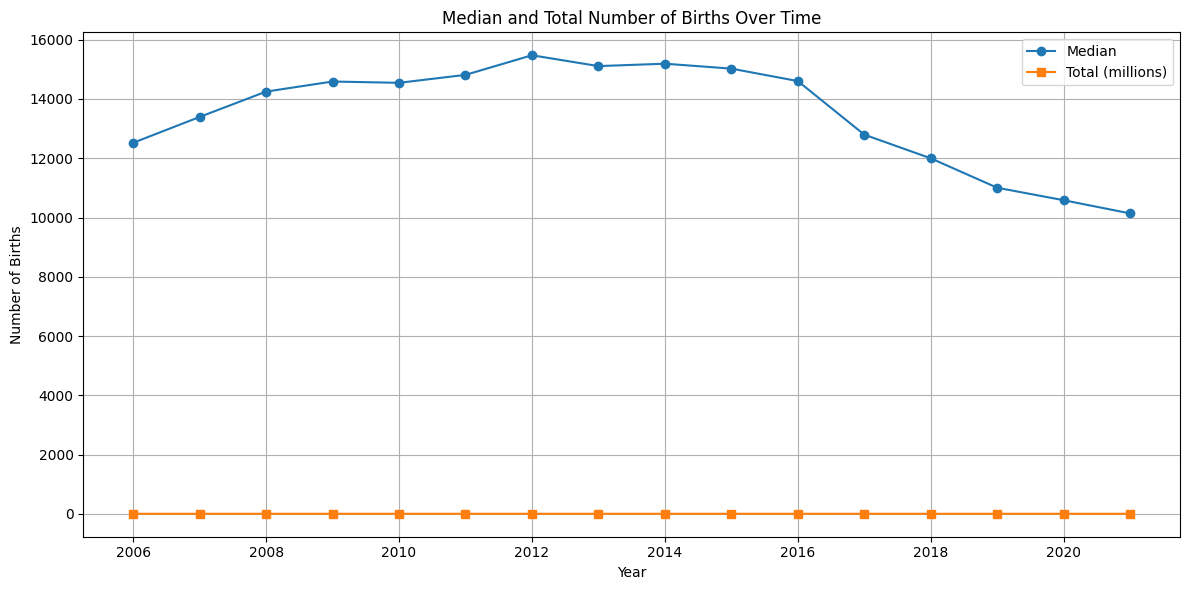

<Figure size 1600x600 with 0 Axes>

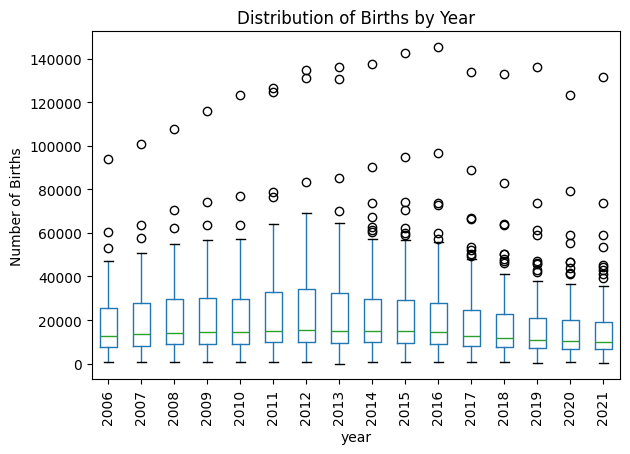

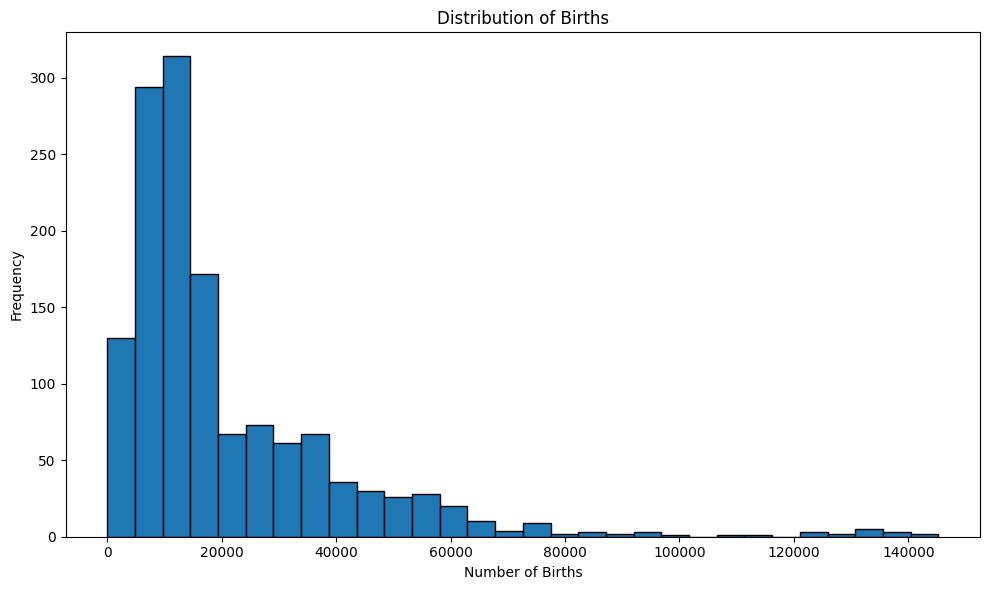

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load data
file_path = "../../outputs/standardized_datasets/newborns_standardized.csv"
df = pd.read_csv(file_path)

# 2. Keep only rows with standardized region names
df = df[df["region_standard"].notna()].copy()

# 3. Remove incomplete year (2022)
df = df[df["year"] < 2022]

# 4. Check data quality
print(df.info())
print("\nMissing values by column:\n", df.isnull().sum())

# 5. Number of unique regions and years
print("\nNumber of unique regions:", df["region_standard"].nunique())
print("Number of unique years:", df["year"].nunique())

# 6. Summary statistics
print("\nBirth statistics:\n", df["births"].describe())

# 7. Duplicates
duplicates = df.duplicated().sum()
print("\nNumber of duplicates:", duplicates)

# 8. Outliers (IQR)
Q1 = df["births"].quantile(0.25)
Q3 = df["births"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["births"] < lower_bound) |
    (df["births"] > upper_bound)
]

print("\nNumber of outliers:", outliers.shape[0])

# 9. Top-5 highest values
top5 = df.sort_values(by="births", ascending=False).head(5)
print("\nTop-5 observations:\n", top5[["region_standard", "year", "births"]])

# 10. Median and total trends
median_births = df.groupby("year")["births"].median()
total_births = df.groupby("year")["births"].sum()

plt.figure(figsize=(12,6))
plt.plot(median_births.index, median_births.values, marker="o", label="Median")
plt.plot(total_births.index, total_births.values / 1e6, marker="s", label="Total (millions)")
plt.title("Median and Total Number of Births Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Births")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 11. Boxplot
plt.figure(figsize=(16,6))
df.boxplot(column="births", by="year", grid=False, rot=90)
plt.title("Distribution of Births by Year")
plt.suptitle("")
plt.ylabel("Number of Births")
plt.tight_layout()
plt.show()

# 12. Histogram
plt.figure(figsize=(10,6))
plt.hist(df["births"], bins=30, edgecolor="black")
plt.title("Distribution of Births")
plt.xlabel("Number of Births")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# EDA of `newborns_standardized.csv`

## Data Description
- The dataset contains 1,369 observations across 85 regions.
- Time coverage: 2005–2021.
- Key variable: number of births by region and year.

---

## Data Types
- All variables are correctly formatted:
  - `year`: int64  
  - `births`: float64  
  - `region_standard`: object  

---

## Missing Values
- No missing values are present.

---

## Duplicates
- No duplicate records were found.

---

## Summary Statistics
- Mean: ~21,200 births  
- Median: ~14,000  
- Minimum: 0  
- Maximum: ~145,000 (Moscow)  
- 75% of observations are below ~28,500  

The gap between mean and median indicates a right-skewed distribution driven by highly populated regions.

---

## Outliers
- Number of outliers (IQR): 85 observations.  
- These correspond to large regions such as Moscow and other major population centers.  
- Outliers are retained, as they reflect real demographic differences.  

---

## Top-5 Regions by Births
1. Moscow — up to ~145,000 births per year  
2. Moscow Oblast — ~90,000  
3. Krasnodar Krai — ~70,000  
4. Republic of Bashkortostan — ~63,000  
5. Republic of Tatarstan — ~60,000  

---

## Trends Over Time
- Median births across regions remain relatively stable.  
- Total births show a slight decline after a peak around 2014–2016.  
- Changes in total births are primarily driven by large regions.  

---

## Distribution Patterns
- Boxplots show moderate dispersion with a clear upper tail driven by large regions.  
- Most regions fall below ~30,000 births per year.  
- The distribution reflects strong population-driven differences.  

---

## Interpretation
- The number of births is strongly influenced by population size (scale effect).  
- Larger regions naturally exhibit higher absolute birth counts.  
- This variable captures demographic dynamics rather than structural differences between regions.  

For meaningful comparisons, birth rates (per capita) would be more informative than absolute counts.

---

## Conclusion
The dataset is clean and ready for further analysis.

Birth data provides important demographic context and helps explain variation across regions, but should be used carefully in modeling, as it primarily reflects scale rather than structural differences.

In [2]:
df.to_csv("../../data/clean/newborns_AfterEDA.csv", index=False)